In [5]:
# import requests
# import pandas as pd
# from datetime import datetime, timedelta

# API_KEY = "6206e4e96646c240ac59f09bc0164ff9"

# start_date = datetime(2025, 1, 1)
# end_date = datetime(2025, 12, 31)

# rows = []

# current = start_date

# while current <= end_date:

#     target_dt = current.strftime("%Y%m%d")

#     url = (
#         "http://www.kobis.or.kr/kobisopenapi/webservice/rest/"
#         f"boxoffice/searchDailyBoxOfficeList.json"
#         f"?key={API_KEY}&targetDt={target_dt}"
#     )

#     result = requests.get(url).json()

#     boxoffice = result['boxOfficeResult']['dailyBoxOfficeList']

#     for movie in boxoffice:

#         rows.append({
#             '날짜': target_dt,
#             '순위': movie['rank'],
#             '영화명': movie['movieNm'],
#             '개봉일': movie['openDt'],
#             '일일관객수': movie['audiCnt'],
#             '누적관객수': movie['audiAcc'],
#             '일일매출액': movie['salesAmt']
#         })

#     current += timedelta(days=1)

# df = pd.DataFrame(rows)
import warnings
warnings.filterwarnings(action='ignore')

import pandas as pd
import numpy as np

df = pd.read_csv('data/kobis.csv')

print(df.head())

           날짜  순위              영화명         개봉일   일일관객수    누적관객수       일일매출액
0  2025-01-01   1              하얼빈  2024-12-24  340484  3095720  3290065760
1  2025-01-01   2   보고타: 마지막 기회의 땅  2024-12-31   93154   194095   880276910
2  2025-01-01   3              소방관  2024-12-04   80830  3398126   769063260
3  2025-01-01   4           수퍼 소닉3  2025-01-01   75916    97373   705207940
4  2025-01-01   5  뽀로로 극장판 바닷속 대모험  2025-01-01   58882    92837   512345060


In [6]:
df.shape

(3650, 7)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   날짜      3650 non-null   object
 1   순위      3650 non-null   int64 
 2   영화명     3650 non-null   object
 3   개봉일     3650 non-null   object
 4   일일관객수   3650 non-null   int64 
 5   누적관객수   3650 non-null   int64 
 6   일일매출액   3650 non-null   int64 
dtypes: int64(4), object(3)
memory usage: 199.7+ KB


In [8]:
df.head()

,날짜,순위,영화명,개봉일,일일관객수,누적관객수,일일매출액
0,2025-01-01,1,하얼빈,2024-12-24,340484,3095720,3290065760
1,2025-01-01,2,보고타: 마지막 기회의 땅,2024-12-31,93154,194095,880276910
2,2025-01-01,3,소방관,2024-12-04,80830,3398126,769063260
3,2025-01-01,4,수퍼 소닉3,2025-01-01,75916,97373,705207940
4,2025-01-01,5,뽀로로 극장판 바닷속 대모험,2025-01-01,58882,92837,512345060


In [9]:
# df 객체를 파일로 저장
df.to_csv('data/kobis.csv', encoding='utf-8', index=False)

- 월별 박스오피스 1등 리스트업

In [10]:
df.dtypes

날짜       object
순위        int64
영화명      object
개봉일      object
일일관객수     int64
누적관객수     int64
일일매출액     int64
dtype: object

In [11]:
# 년, 월, 일, 요일 컬럼 생성
df['날짜'] = pd.to_datetime(df['날짜'])
df.dtypes

날짜       datetime64[ns]
순위                int64
영화명              object
개봉일              object
일일관객수             int64
누적관객수             int64
일일매출액             int64
dtype: object

In [12]:
df['연도'] = df['날짜'].dt.year
df['월'] = df['날짜'].dt.month
df['일'] = df['날짜'].dt.day
df['요일'] = df['날짜'].dt.weekday
df

,날짜,순위,영화명,개봉일,일일관객수,누적관객수,일일매출액,연도,월,일,요일
0,2025-01-01,1,하얼빈,2024-12-24,340484,3095720,3290065760,2025,1,1,2
1,2025-01-01,2,보고타: 마지막 기회의 땅,2024-12-31,93154,194095,880276910,2025,1,1,2
2,2025-01-01,3,소방관,2024-12-04,80830,3398126,769063260,2025,1,1,2
3,2025-01-01,4,수퍼 소닉3,2025-01-01,75916,97373,705207940,2025,1,1,2
4,2025-01-01,5,뽀로로 극장판 바닷속 대모험,2025-01-01,58882,92837,512345060,2025,1,1,2
...,...,...,...,...,...,...,...,...,...,...,...
3645,2025-12-31,6,극장판 짱구는 못말려: 초화려! 작열하는 떡잎마을 댄서즈,2025-12-24,18979,327390,154747310,2025,12,31,2
3646,2025-12-31,7,화양연화 특별판,2025-12-31,9292,11279,80027452,2025,12,31,2
3647,2025-12-31,8,뽀로로 극장판 스위트캐슬 대모험,2025-12-11,4807,216003,41105520,2025,12,31,2
3648,2025-12-31,9,누벨바그,2025-12-31,4051,4597,24782960,2025,12,31,2


In [35]:
df.dtypes

날짜       datetime64[ns]
순위               object
영화명              object
개봉일              object
일일관객수            object
누적관객수            object
일일매출액            object
연도                int32
월                 int32
일                 int32
요일                int32
dtype: object

In [13]:
# 요일 변경
week_dict = {
    0: '월요일',
    1: '화요일',
    2: '수요일',
    3: '목요일',
    4: '금요일',
    5: '토요일',
    6: '일요일'
}
week_dict
df['요일'] = df['날짜'].dt.weekday.map(week_dict)
df['요일'].value_counts()

요일
수요일    530
목요일    520
금요일    520
토요일    520
일요일    520
월요일    520
화요일    520
Name: count, dtype: int64

In [22]:
df.dtypes

날짜       datetime64[ns]
순위                int64
영화명              object
개봉일              object
일일관객수             int64
누적관객수             int64
일일매출액             int64
연도                int32
월                 int32
일                 int32
요일               object
dtype: object

In [15]:
df['순위'].value_counts()

순위
1     365
2     365
3     365
4     365
5     365
6     365
7     365
8     365
9     365
10    365
Name: count, dtype: int64

In [23]:
df_rank1 = df[df['순위'] == 1]
df_rank1

,날짜,순위,영화명,개봉일,일일관객수,누적관객수,일일매출액,연도,월,일,요일
0,2025-01-01,1,하얼빈,2024-12-24,340484,3095720,3290065760,2025,1,1,수요일
10,2025-01-02,1,하얼빈,2024-12-24,92862,3188582,850528040,2025,1,2,목요일
20,2025-01-03,1,하얼빈,2024-12-24,91398,3279980,869700750,2025,1,3,금요일
30,2025-01-04,1,하얼빈,2024-12-24,218542,3498522,2140702910,2025,1,4,토요일
40,2025-01-05,1,하얼빈,2024-12-24,174400,3672922,1698746070,2025,1,5,일요일
...,...,...,...,...,...,...,...,...,...,...,...
3600,2025-12-27,1,아바타: 불과 재,2025-12-17,416651,3671395,4882594660,2025,12,27,토요일
3610,2025-12-28,1,아바타: 불과 재,2025-12-17,364963,4036358,4243646380,2025,12,28,일요일
3620,2025-12-29,1,아바타: 불과 재,2025-12-17,138756,4175114,1602159840,2025,12,29,월요일
3630,2025-12-30,1,아바타: 불과 재,2025-12-17,138613,4313727,1573424620,2025,12,30,화요일


In [33]:
# 2025년도 기준, Top of Top 10
df_rank1_top10 = df.groupby('영화명')['일일관객수'].sum().sort_values(ascending=False).head(10)

In [34]:
import matplotlib.pyplot as plt

In [36]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import platform

if platform.system() == 'Windows':
    matplotlib.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    matplotlib.rc('font', family='AppleGothic')
else:
    matplotlib.rc('font', family='DejaVu Sans')

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

print('NumPy 버전:', np.__version__)
print('환경 설정 완료')

NumPy 버전: 2.3.5
환경 설정 완료


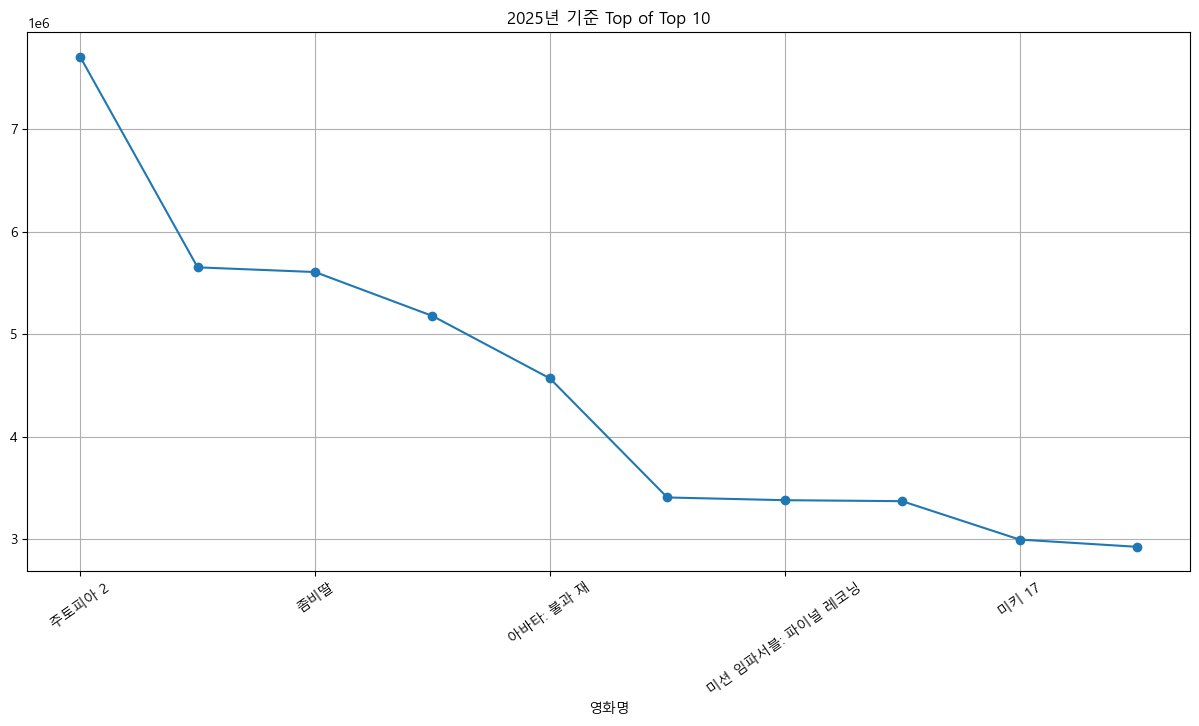

In [43]:
df_rank1_top10.plot(
    kind='line',
    marker='o',
    figsize=(15, 7)
)
plt.title('2025년 기준 Top of Top 10')
plt.grid()
plt.xticks(rotation=35)
plt.show()

In [68]:
# 월별 총 매출액 기준 Top 10
# 그래프 생성 시 월별로 정렬
monthly_sold = df.groupby('월')['일일매출액'].sum()
monthly_sold

월
1      76426460660
2      47082683466
3      55772809470
4      46966204130
5      77570405180
6      69262625020
7     108647423776
8     126989955840
9      70064275110
10     89208664310
11     65397825630
12    134856286132
Name: 일일매출액, dtype: int64

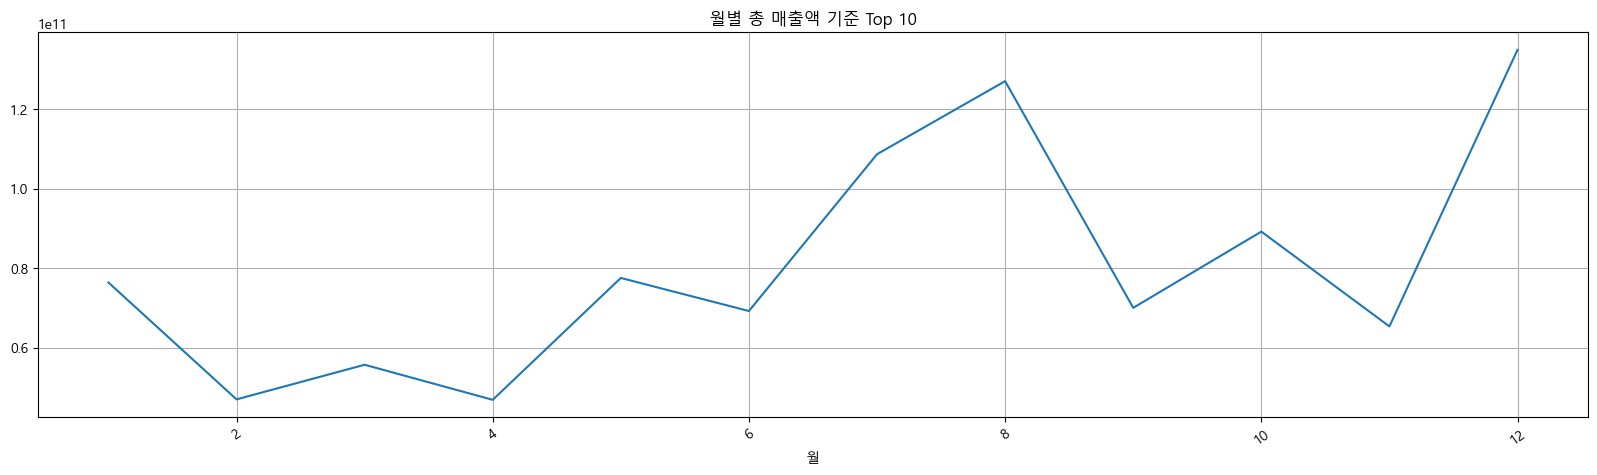

In [70]:
monthly_sold.plot(
    kind='line',
        
    figsize=(20, 5)
)
plt.title('월별 총 매출액 기준 Top 10')
plt.grid()
plt.xticks(rotation=35)
plt.show()

In [71]:
# 요일별 일일관객수 추이
df.dtypes

날짜       datetime64[ns]
순위                int64
영화명              object
개봉일              object
일일관객수             int64
누적관객수             int64
일일매출액             int64
연도                int32
월                 int32
일                 int32
요일               object
dtype: object

In [93]:
weekday = ['월요일', '화요일', '수요일', '목요일', '금요일', '토요일', '일요일']
daily_gallery = df.groupby('요일')['일일관객수'].sum().reindex(weekday)
daily_gallery

요일
월요일     8318811
화요일     7951556
수요일    12657300
목요일    10303793
금요일    13034054
토요일    24433622
일요일    21394197
Name: 일일관객수, dtype: int64

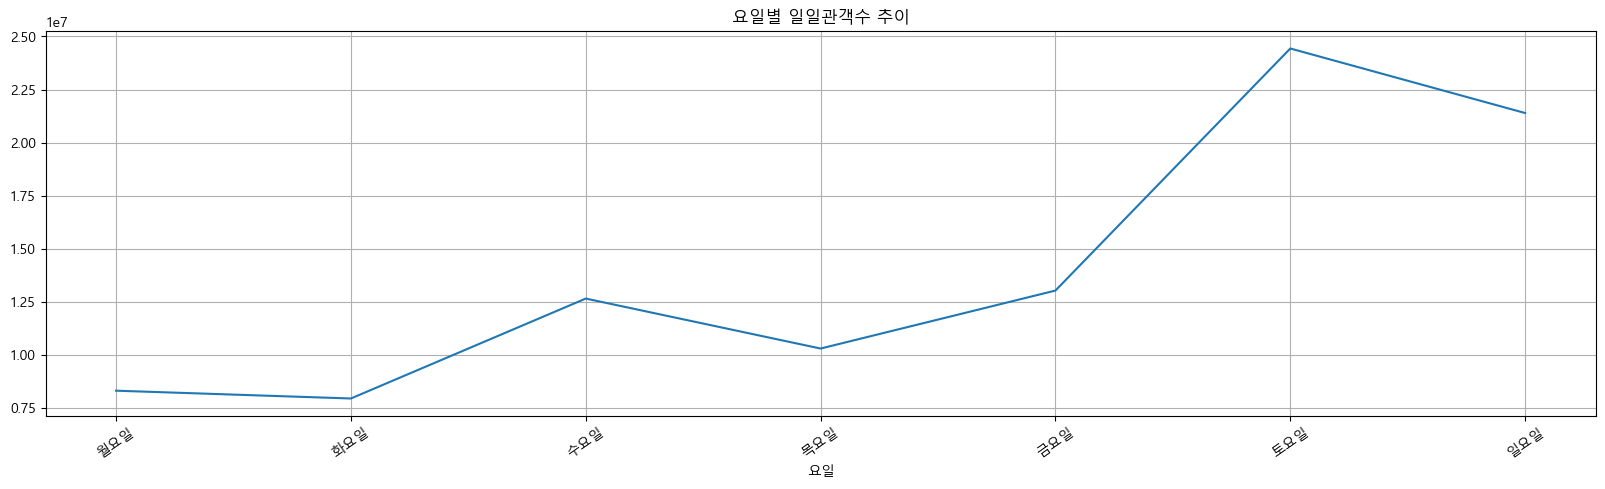

In [94]:
daily_gallery.plot(
    kind='line',
    figsize=(20, 5)
)
plt.title('요일별 일일관객수 추이')
plt.grid()
plt.xticks(rotation=35)
plt.show()